<a href="https://colab.research.google.com/github/rafaeldebarros/MVP_analise_exploratoria/blob/main/MVP_An%C3%A1lise_explorat%C3%B3ria_de_dados_e_boas_pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de dados e boas práticas

Nome: Rafael Souza de Barros
Matrícula:
Dataset: Student Performance

## Descrição



##

In [11]:
## Instalando as bibliotecas necessárias

!pip install ucimlrepo

## Importando as bibliotecas necessárias
# Import the dataset into your code
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics




In [12]:
# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
x = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

In [13]:
## Conferindo o dataframe
x.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0
5,GP,M,16,U,LE3,T,4,3,services,other,...,yes,yes,no,5,4,2,1,2,5,6
6,GP,M,16,U,LE3,T,2,2,other,other,...,yes,yes,no,4,4,4,1,1,3,0
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,yes,no,no,4,1,4,1,1,1,2
8,GP,M,15,U,LE3,A,3,2,services,other,...,yes,yes,no,4,2,2,1,1,1,0
9,GP,M,15,U,GT3,T,3,4,other,other,...,yes,yes,no,5,5,1,1,1,5,0


In [20]:
x.count()

,0
school,649
sex,649
age,649
address,649
famsize,649
Pstatus,649
Medu,649
Fedu,649
Mjob,649
Fjob,649


In [14]:
# verificando nulls no dataset
x.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


## Estatísticas Descritivas para Todas as Variáveis

In [36]:
display(df_combined_fe.describe(include='all'))

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,parental_education,total_alcohol_consumption,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,...,649,649,649,649,649,649.000000,649.000000,649.000000,649.000000,649.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,True,True,True,False,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,334,521,580,498,410,NaN,NaN,NaN,NaN,NaN
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,...,NaN,NaN,NaN,NaN,NaN,2.410632,3.782743,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,...,NaN,NaN,NaN,NaN,NaN,1.014035,1.992411,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,0.000000,2.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,1.500000,2.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,2.500000,3.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,3.000000,5.000000,13.000000,13.000000,14.000000


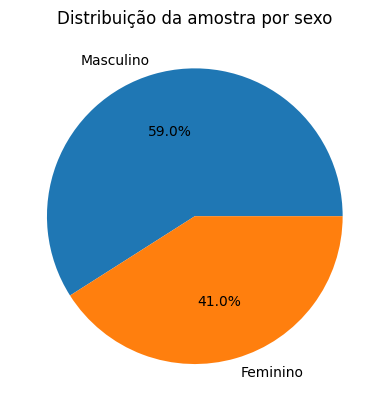

In [9]:
## Analisando o dataframe

### Distribuição da amostra por sexo
plt.pie(x['sex'].value_counts(), labels=['Masculino', 'Feminino'], autopct='%1.1f%%')
plt.title('Distribuição da amostra por sexo')
plt.show()


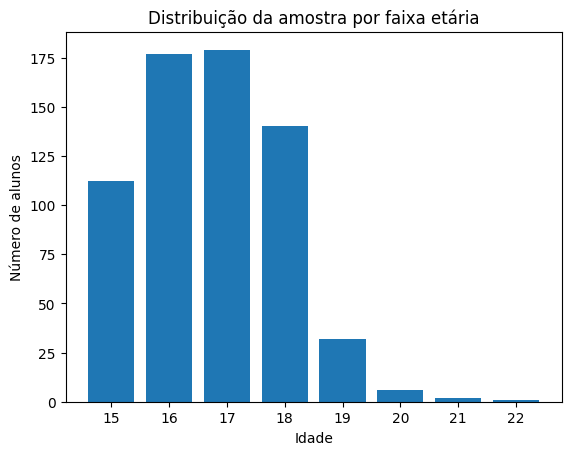

In [10]:
### Distribuição da amostra por faixa etária
age_counts = x['age'].value_counts().sort_index()
plt.bar(age_counts.index, age_counts.values)
plt.title('Distribuição da amostra por faixa etária')
plt.xlabel('Idade')
plt.ylabel('Número de alunos')
plt.show()

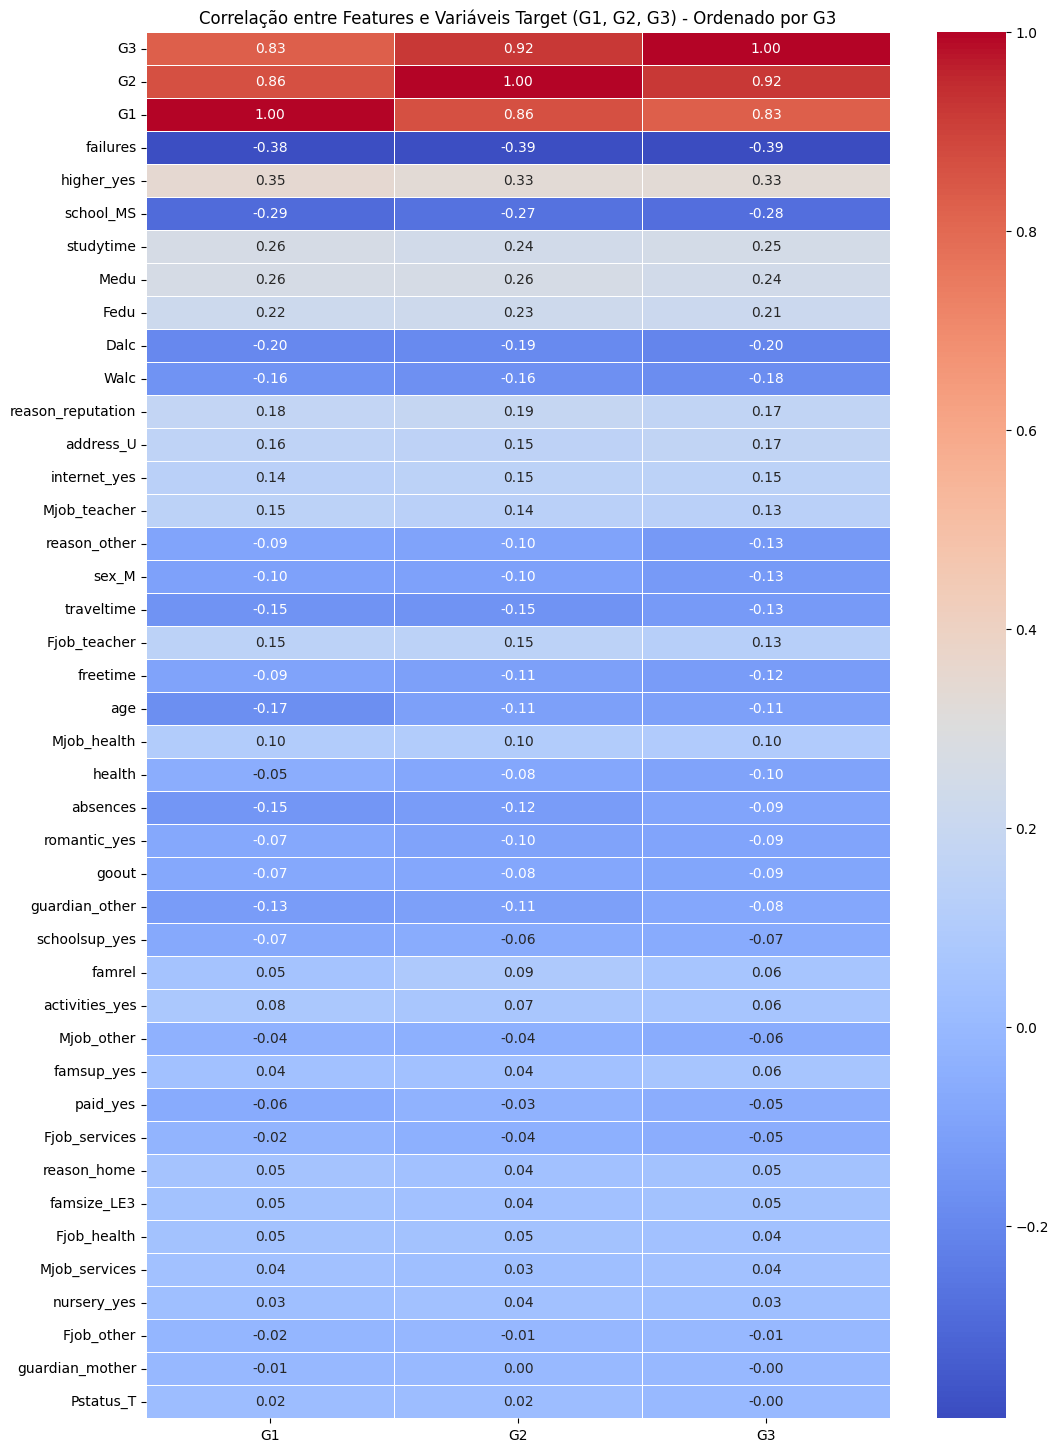

In [15]:
# Identificar colunas categóricas em X
categorical_cols = x.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding nas colunas categóricas
x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

# Combinar features processadas com as variáveis target
df_combined = pd.concat([x_encoded, y], axis=1)

# Calcular a matriz de correlação
correlation_matrix = df_combined.corr()

# Selecionar apenas as correlações com as variáveis target
target_correlations = correlation_matrix[y.columns]

# Ordenar a matriz de correlação pela correlação absoluta com G3 em ordem decrescente
target_correlations_sorted = target_correlations.loc[target_correlations['G3'].abs().sort_values(ascending=False).index]

# Plotar o heatmap das correlações com os targets
plt.figure(figsize=(12, 18))
sns.heatmap(target_correlations_sorted, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre Features e Variáveis Target (G1, G2, G3) - Ordenado por G3')
plt.show()

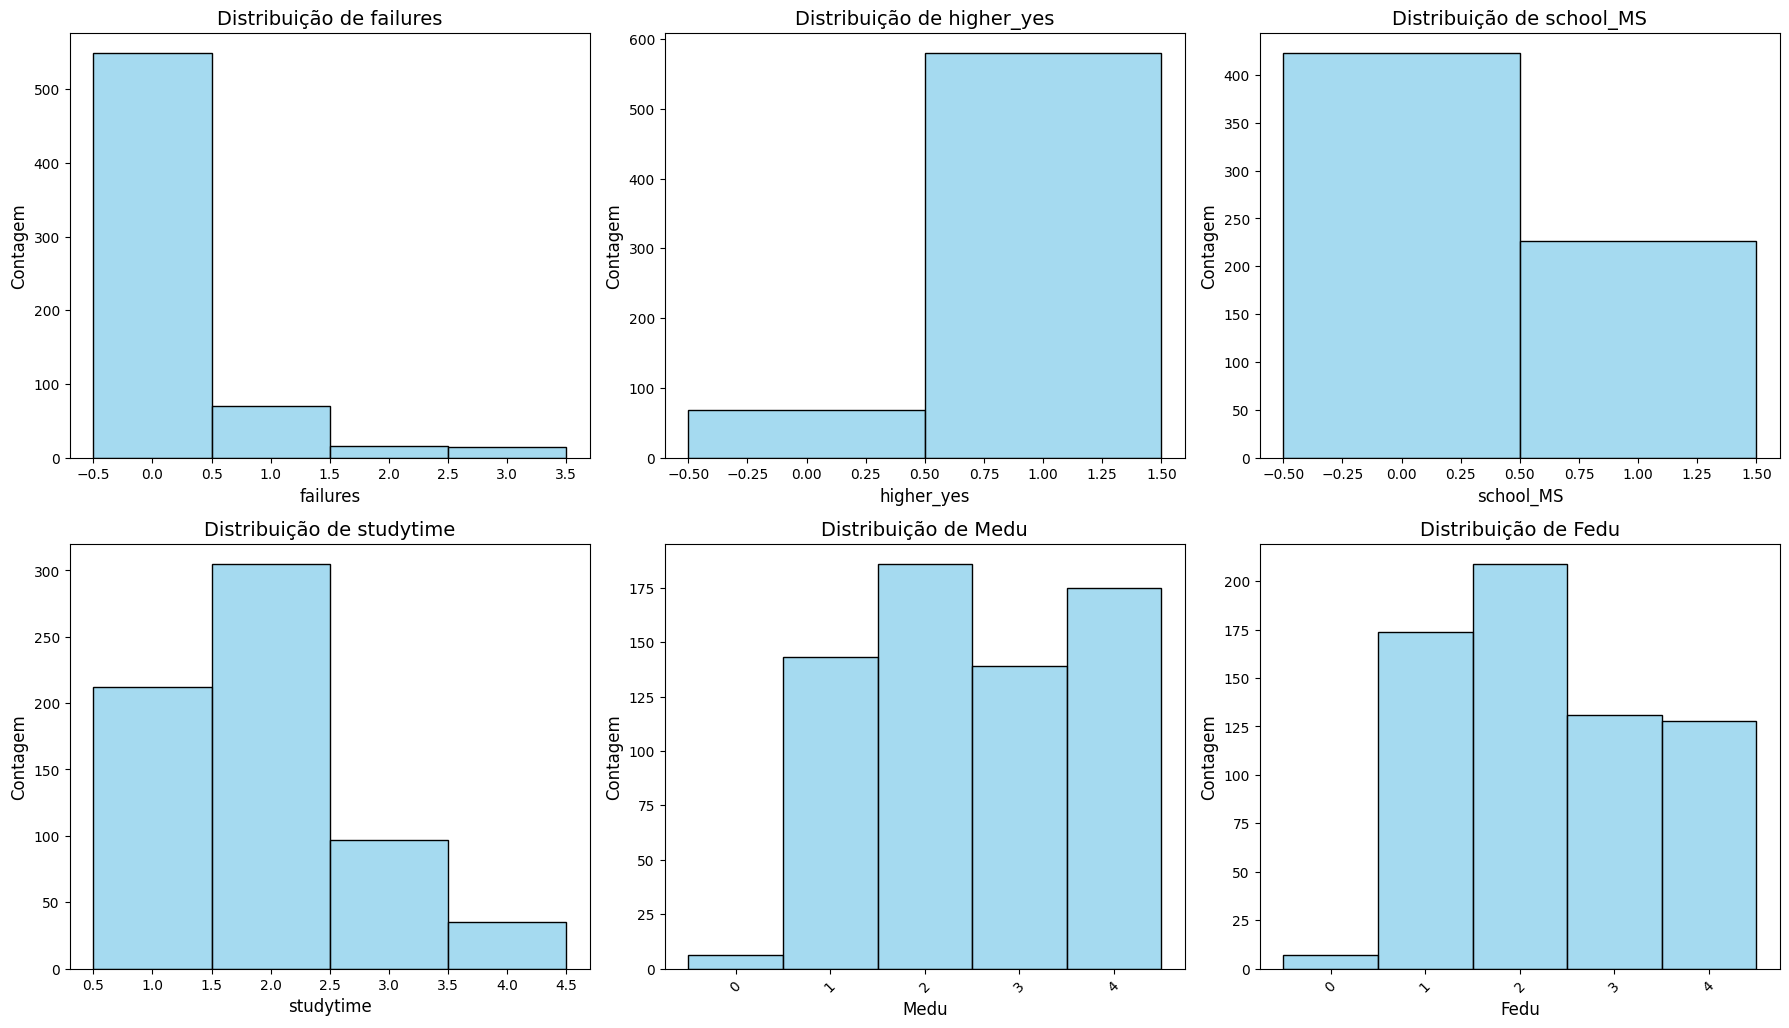

In [16]:
columns_to_plot = ['failures', 'higher_yes', 'school_MS', 'studytime', 'Medu', 'Fedu']

# Create a figure and a set of subplots with 3 rows and 3 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

# Iterate through the columns and plot a histogram for each
for i, col in enumerate(columns_to_plot):
    sns.histplot(data=x_encoded, x=col, ax=axes[i], discrete=True, color='skyblue')
    axes[i].set_title(f'Distribuição de {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Contagem', fontsize=12)
    # Rotate x-axis labels for better readability, especially for job columns
    if col in ['Fedu', 'Medu']:
        axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Gráficos de Dispersão das 6 Features Mais Correlacionadas com G3

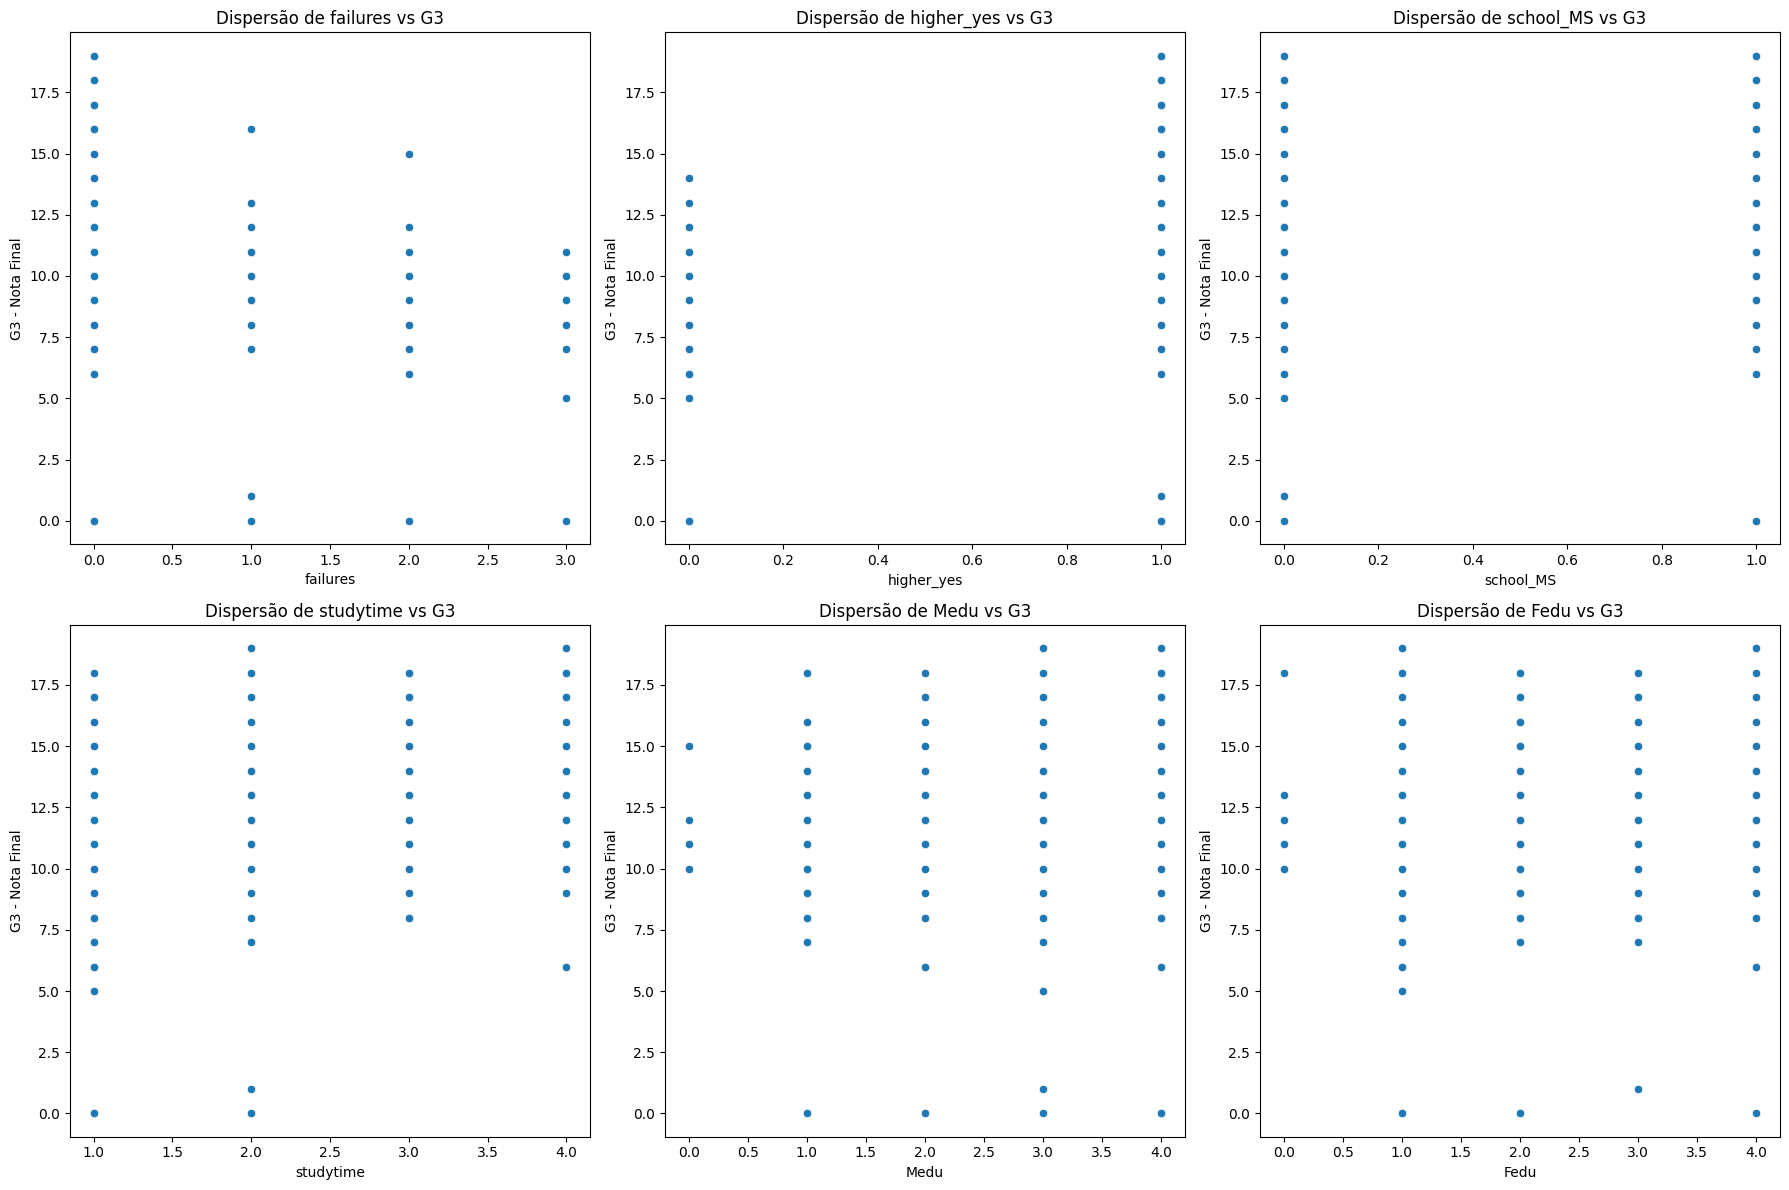

In [17]:
# Obter as 6 variáveis com maior correlação absoluta com G3 (excluindo G1, G2, G3)
# Já temos `top_correlated_vars` definida que contém as 20 features mais correlacionadas.
# Vamos selecionar as primeiras 6 desta lista que são as mais relevantes.
# Garante que as variáveis G1 e G2 não sejam plotadas como features, já que são as notas intermediárias.

# Filtrar as 6 primeiras que não são G1, G2, G3
final_top_6_features = [col for col in target_correlations_sorted.index if col not in ['G1', 'G2', 'G3']][:6]

plt.figure(figsize=(18, 12))
for i, col in enumerate(final_top_6_features):
    plt.subplot(2, 3, i + 1) # 2 linhas, 3 colunas para os plots
    sns.scatterplot(x=df_combined[col], y=df_combined['G3'])
    plt.title(f'Dispersão de {col} vs G3')
    plt.xlabel(col)
    plt.ylabel('G3 - Nota Final')

plt.tight_layout()
plt.show()

## Análise de Outliers nas Variáveis Mais Correlacionadas com G3

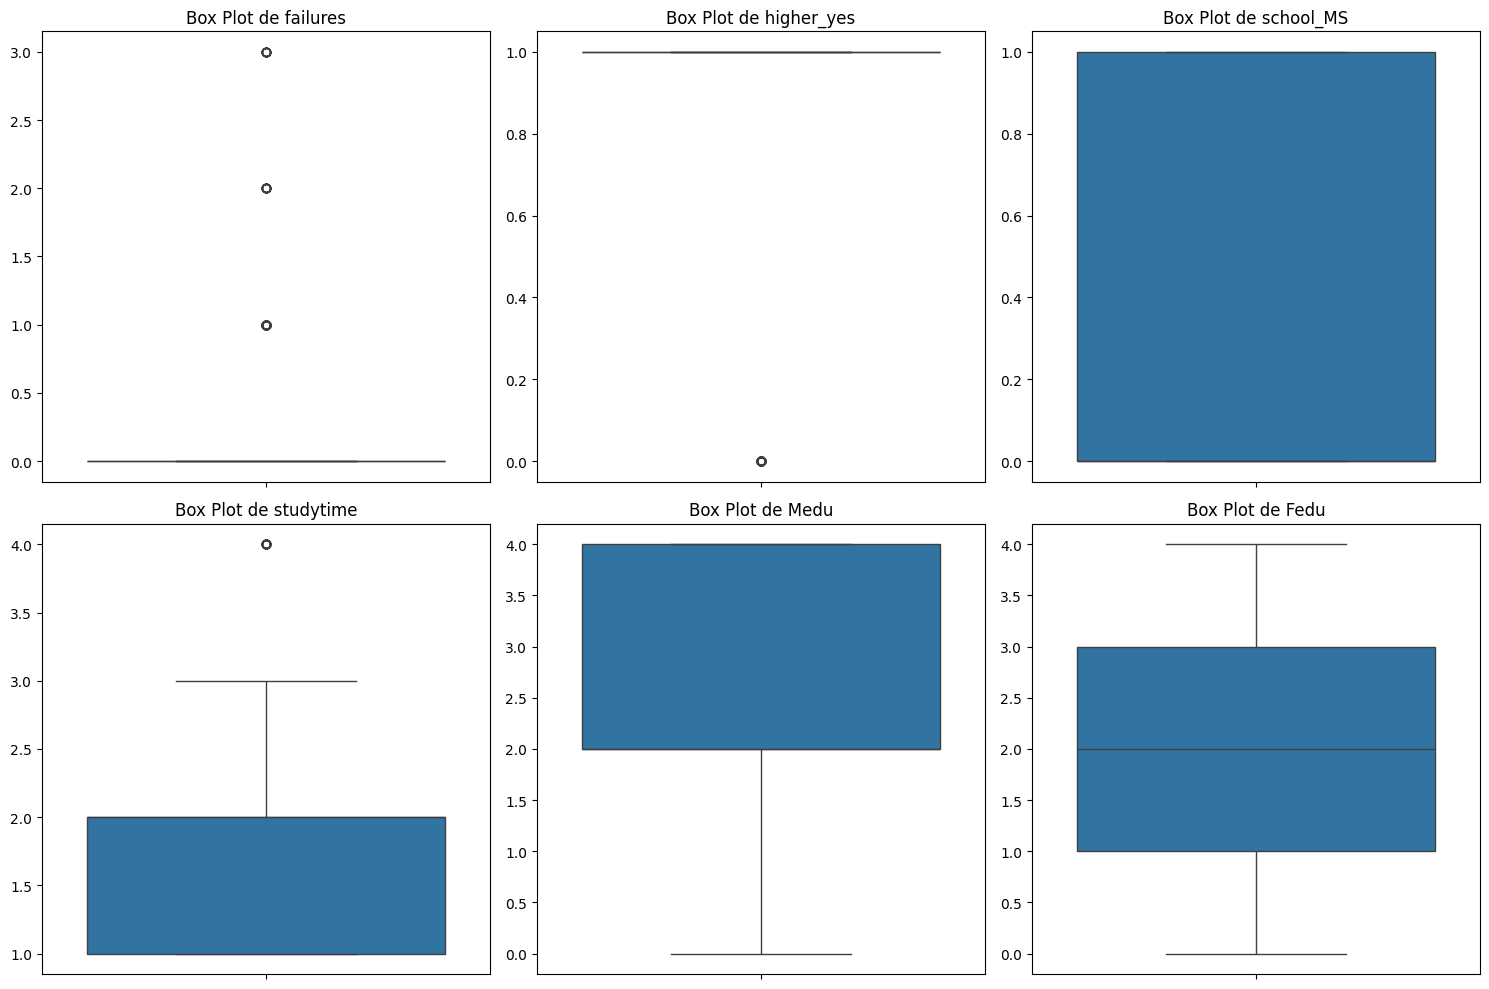

In [18]:
# Obter as 6 variáveis com maior correlação absoluta com G3 (excluindo G1, G2, G3)
top_correlated_vars = target_correlations_sorted.index.drop(['G1', 'G2', 'G3'], errors='ignore').tolist()[:6]

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_correlated_vars):
    plt.subplot(2, 3, i + 1) # 2 linhas, 3 colunas para os plots
    sns.boxplot(y=df_combined[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel('') # Remover rótulo do eixo y para evitar redundância

plt.tight_layout()
plt.show()

## Treinando o Modelo de Regressão Linear e Analisando os Resíduos

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Obter as 20 variáveis com maior correlação absoluta com G3 (excluindo G1, G2, G3)
top_correlated_vars = target_correlations_sorted.index.drop(['G1', 'G2', 'G3'], errors='ignore').tolist()[:20]

# Definir X e y para o modelo de regressão, usando apenas as variáveis selecionadas
X_model = x_encoded[top_correlated_vars].copy()
y_model = y['G3']

In [21]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de treino: 519 amostras
Tamanho do conjunto de teste: 130 amostras


In [22]:
# Inicializar e treinar o modelo de Regressão Linear
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

print("Modelo de Regressão Linear treinado com sucesso utilizando as 6 variáveis mais correlacionadas.")

Modelo de Regressão Linear treinado com sucesso utilizando as 6 variáveis mais correlacionadas.


In [23]:
# Fazer previsões no conjunto de teste
y_pred = linear_reg_model.predict(X_test)

In [24]:
# Avaliar o desempenho do modelo
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error (MAE): 2.10
Mean Squared Error (MSE): 7.77
Root Mean Squared Error (RMSE): 2.79
R2 Score: 0.20


In [25]:
# Calcular os resíduos
residuals = y_test - y_pred

### Distribuição dos Resíduos

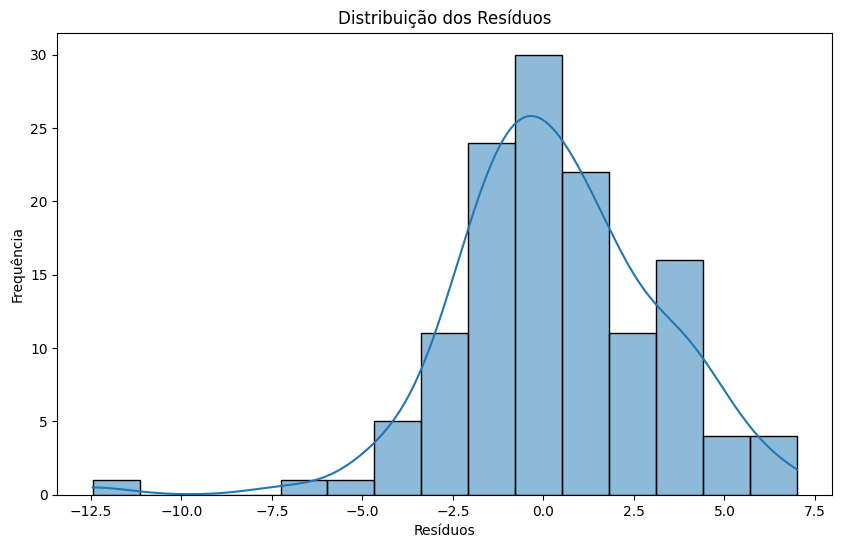

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

### Resíduos vs. Valores Reais

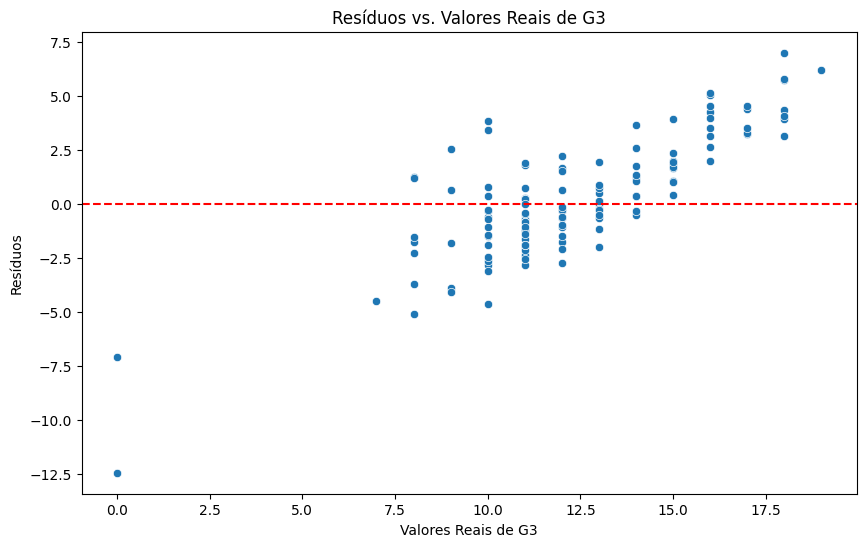

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos vs. Valores Reais de G3')
plt.xlabel('Valores Reais de G3')
plt.ylabel('Resíduos')
plt.show()

## Engenharia de Features: Novas Variáveis

In [28]:
# Criar uma cópia do dataframe codificado para adicionar novas features
df_feature_engineered = x_encoded.copy()

# 1. Educação Parental Média
df_feature_engineered['parental_education'] = (df_feature_engineered['Medu'] + df_feature_engineered['Fedu']) / 2

# 2. Consumo Total de Álcool
df_feature_engineered['total_alcohol_consumption'] = df_feature_engineered['Dalc'] + df_feature_engineered['Walc']

print("Novas features 'parental_education' e 'total_alcohol_consumption' criadas.")

display(df_feature_engineered.head())

Novas features 'parental_education' e 'total_alcohol_consumption' criadas.


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,parental_education,total_alcohol_consumption
0,18,4,4,2,2,0,4,3,4,1,...,True,False,False,False,True,True,False,False,4.0,2
1,17,1,1,1,2,0,5,3,3,1,...,False,True,False,False,False,True,True,False,1.0,2
2,15,1,1,1,2,0,4,3,2,2,...,True,False,False,False,True,True,True,False,1.0,5
3,15,4,2,1,3,0,3,2,2,1,...,False,True,False,True,True,True,True,True,3.0,2
4,16,3,3,1,2,0,4,3,2,1,...,False,True,False,False,True,True,False,False,3.0,3


## Reavaliando Correlações com Novas Features

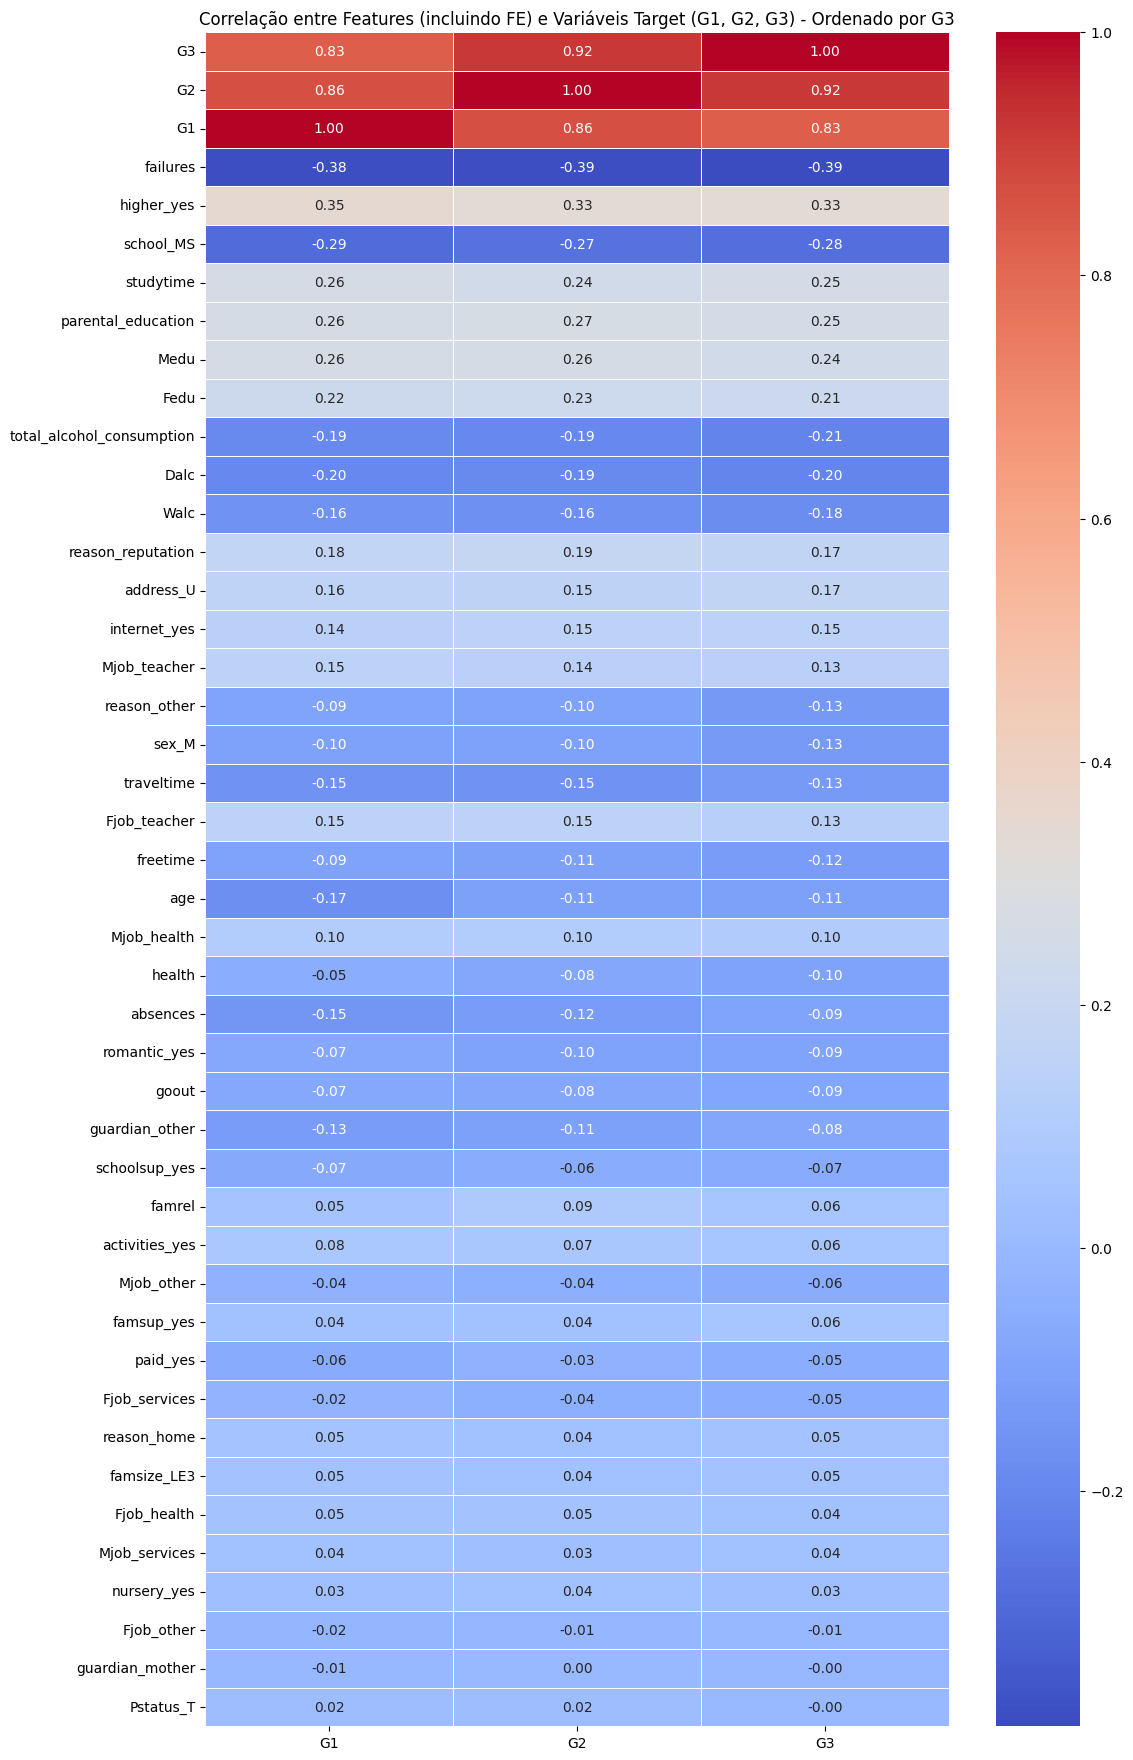

Top 20 features mais correlacionadas com G3 após engenharia de features:
failures                    -0.393316
higher_yes                   0.332172
school_MS                   -0.284294
studytime                    0.249789
parental_education           0.249217
Medu                         0.240151
Fedu                         0.211800
total_alcohol_consumption   -0.208881
Dalc                        -0.204719
Walc                        -0.176619
reason_reputation            0.170944
address_U                    0.167637
internet_yes                 0.150025
Mjob_teacher                 0.134910
reason_other                -0.132577
sex_M                       -0.129077
traveltime                  -0.127173
Fjob_teacher                 0.125916
freetime                    -0.122705
age                         -0.106505
Name: G3, dtype: float64


In [29]:
# Combinar features processadas com as variáveis target, incluindo as novas features
df_combined_fe = pd.concat([df_feature_engineered, y], axis=1)

# Calcular a matriz de correlação
correlation_matrix_fe = df_combined_fe.corr()

# Selecionar apenas as correlações com as variáveis target
target_correlations_fe = correlation_matrix_fe[y.columns]

# Ordenar a matriz de correlação pela correlação absoluta com G3 em ordem decrescente
target_correlations_sorted_fe = target_correlations_fe.loc[target_correlations_fe['G3'].abs().sort_values(ascending=False).index]

# Plotar o heatmap das correlações com os targets, incluindo as novas features
plt.figure(figsize=(12, 22)) # Aumentar o tamanho para acomodar mais features
sns.heatmap(target_correlations_sorted_fe, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação entre Features (incluindo FE) e Variáveis Target (G1, G2, G3) - Ordenado por G3')
plt.show()

print("Top 20 features mais correlacionadas com G3 após engenharia de features:")
print(target_correlations_sorted_fe['G3'].drop(['G1', 'G2', 'G3'], errors='ignore').head(20))

## Matriz de Correlação das 6 Variáveis Mais Correlacionadas com G3 e Variáveis Target

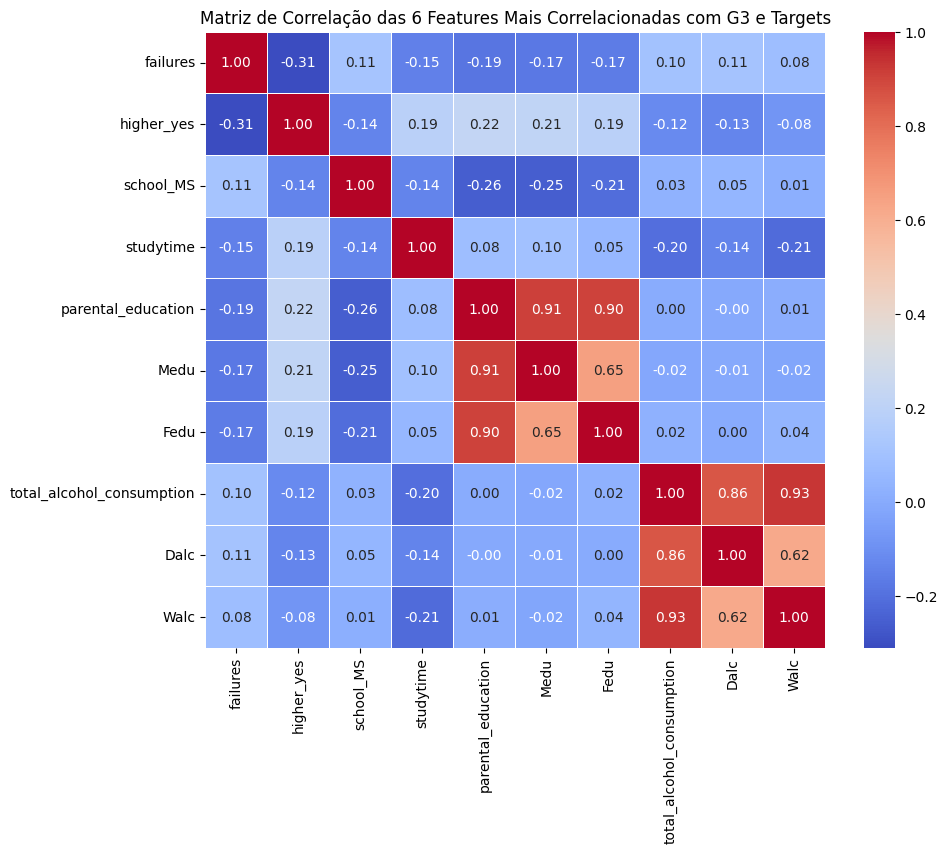

In [70]:
# Obter as 10 variáveis com maior correlação absoluta com G3 (excluindo G1, G2, G3)
top_10_correlated_vars = target_correlations_sorted_fe['G3'].drop(['G1', 'G2', 'G3'], errors='ignore').head(10).index.tolist()

# Selecionar as colunas para a nova matriz de correlação
columns_for_corr_matrix = top_10_correlated_vars

# Criar um DataFrame apenas com as colunas selecionadas
df_selected_for_corr = df_combined_fe[columns_for_corr_matrix]

# Calcular a matriz de correlação para as colunas selecionadas
correlation_matrix_top6 = df_selected_for_corr.corr()

# Plotar o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_top6, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação das 6 Features Mais Correlacionadas com G3 e Targets')
plt.show()

## Treinando Novo Modelo de Regressão Linear com Features Engenheiradas

In [71]:
# Obter as 5 variáveis com maior correlação absoluta com G3, incluindo as novas features
top_correlated_vars_fe = target_correlations_sorted_fe['G3'].drop(['G1', 'G2', 'G3'], errors='ignore').head(5).index.tolist()

# Definir X e y para o modelo de regressão, usando as variáveis selecionadas e as features engenheiradas
X_model_fe = df_feature_engineered[top_correlated_vars_fe].copy()
y_model_fe = y['G3']

# Dividir os dados em conjuntos de treino e teste
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_model_fe, y_model_fe, test_size=0.2, random_state=42)

print(f"Tamanho do conjunto de treino (com FE): {X_train_fe.shape[0]} amostras")
print(f"Tamanho do conjunto de teste (com FE): {X_test_fe.shape[0]} amostras")

Tamanho do conjunto de treino (com FE): 519 amostras
Tamanho do conjunto de teste (com FE): 130 amostras


In [72]:
# Inicializar e treinar o novo modelo de Regressão Linear
linear_reg_model_fe = LinearRegression()
linear_reg_model_fe.fit(X_train_fe, y_train_fe)

print("Novo Modelo de Regressão Linear treinado com sucesso utilizando as features engenheiradas.")

Novo Modelo de Regressão Linear treinado com sucesso utilizando as features engenheiradas.


In [73]:
# Fazer previsões no conjunto de teste
y_pred_fe = linear_reg_model_fe.predict(X_test_fe)

# Avaliar o desempenho do novo modelo
mae_fe = metrics.mean_absolute_error(y_test_fe, y_pred_fe)
mse_fe = metrics.mean_squared_error(y_test_fe, y_pred_fe)
rmse_fe = np.sqrt(mse_fe)
r2_fe = metrics.r2_score(y_test_fe, y_pred_fe)

print(f'Mean Absolute Error (MAE) com FE: {mae_fe:.2f}')
print(f'Mean Squared Error (MSE) com FE: {mse_fe:.2f}')
print(f'Root Mean Squared Error (RMSE) com FE: {rmse_fe:.2f}')
print(f'R2 Score com FE: {r2_fe:.2f}')

Mean Absolute Error (MAE) com FE: 2.11
Mean Squared Error (MSE) com FE: 7.87
Root Mean Squared Error (RMSE) com FE: 2.81
R2 Score com FE: 0.19


In [74]:
# Calcular os resíduos do novo modelo
residuals_fe = y_test_fe - y_pred_fe

### Distribuição dos Resíduos (Regressão Linear com Features Engenheiradas)

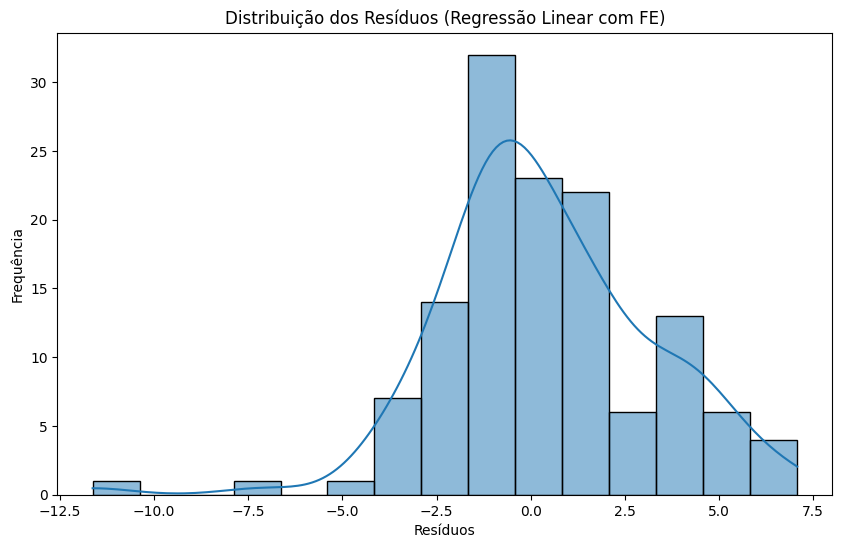

In [75]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals_fe, kde=True)
plt.title('Distribuição dos Resíduos (Regressão Linear com FE)')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.show()

### Resíduos vs. Valores Reais (Regressão Linear com Features Engenheiradas)

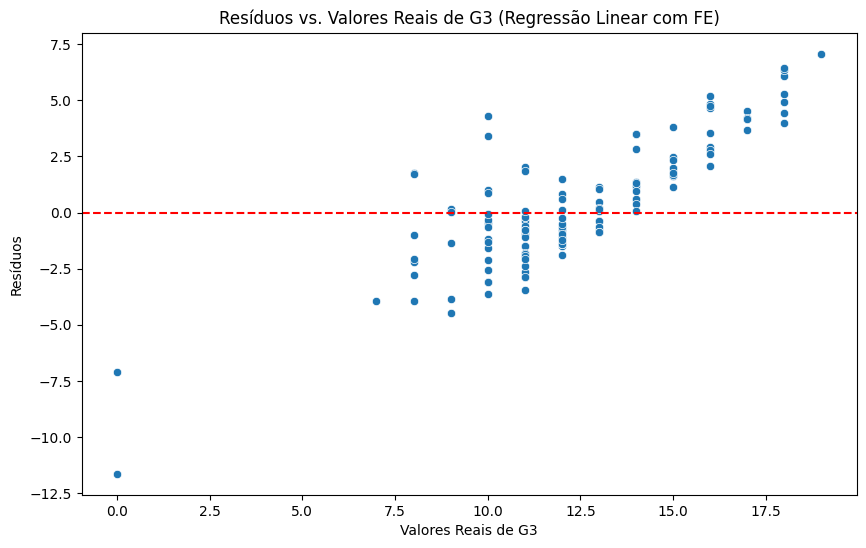

In [76]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_fe, y=residuals_fe)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos vs. Valores Reais de G3 (Regressão Linear com FE)')
plt.xlabel('Valores Reais de G3')
plt.ylabel('Resíduos')
plt.show()